# Anexo 2

## Dataset: Informe de análisis

### Descarga del dataset
El dataset se puede descargar en el siguiente [enlace](http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz). Se ha usado el comando _wget -c http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz_

### Descipción del dataset
El dataset\[1\], recopilado y preparado por Pete Warden, se compone de los siguientes comandos de una sóla palabra obtenidos a través de *crowdsourcing*: "Yes", "No", "Up", "Down", "Left", "Right", "On", "Off", "Stop", "Go", "Zero", "One", "Two", "Three", "Four", "Five", "Six", "Seven", "Eight", y "Nine".
Además, se incluyen diez palabras auxiliares, con el propósito inicial de distinguir palabras no reconocidas: "Bed", "Bird", "Cat", "Dog", "Happy", "House", "Marvin", "Sheila", "Tree", y "Wow".

El dataset incluye también 6 archivos de ruido de ambiente concebidos para ser mezclados con los comandos en pipelines de aumentación.

**Estructura:**

Los archivos están organizados por comandos en directorios, y nombrados como *idHablante\_nohash\_n.wav*, donde idHablante es un identificador relacionado con la persona que ha grabado el audio, n es un número que indica el número de toma realizada y *nohash* es una cadena estable que se añade al nombre para facilitar la programación de un script que se ha usado para particionar los archivos en conjuntos de entrenamiento, testing y validación. La razón de esto es que el script discrimina los archivos de cada hablante para mantenerlos dentro del mismo conjunto y evitar así contaminar los datasets de validación y testing. El script se incluye en el README.md del dataset, y realiza las particiones a partir de un hash del nombre del archivo y el tamaño deseado para los conjuntos.

En lugar de mover los archivos en los distintos conjuntos, se crean unas listas con las rutas en archivos de texto para poder iterar sobre su contenido.

**Formato:**
Las muestras no se han capturado en el mismo formato, pero este se ha unificado en archivos WAV con codificación PCM Little-endian, a 16 kHz y 16-bit.

**Modificaciones:**
El dataset viene con la duración de las muestras igualadas a un segundo por medio de la herremienta [extract\_loudest\_section](https://github.com/petewarden/extract_loudest_section) de Pete Warden.

### Análisis

Aunque el dataset original está ya documentado, vamos a realizar unas comprobaciones para asegurarnos de que el dataset descargado no presenta ningún problema. La ruta en la que se ha descomprimido el dataset se ha definido en ROOTPATH, y es _/mnt/data/GSC/speech_commands_v0.02_. Para ejecutar los snippets de código es necesario adecuar ROOTPATH al valor correspondiente en cada sistema.

In [1]:
from pathlib import Path                                                                     
import pandas as pd                                                                          
import torch                                                                                 
import torchaudio                                                                            
import torchaudio.functional as F                                                            
import matplotlib.pyplot as plt                                                              
                                                                                             
#Recorremos el dataset para extraer información y guardarla en un dataframe de pandas        
ROOTPATH = Path('/mnt/data/GSC/speech_commands_v0.02')                                       
                                                                                             
def extract_info(filepath):                                                                  
    info = torchaudio.info(str(filepath))                                                    
    nch = info.num_channels                                                                  
    sr = info.sample_rate                                                                    
    nframes = info.num_frames                                                                
    duration = None if sr is None else nframes/sr                                            
    return nch, sr, nframes, duration                                                        
rows = []                                                                                    
                                                                                             
#Recorremos el directorio root en orden alfabético                                           
for filepath in sorted(ROOTPATH.rglob('*.wav'), key=lambda l : str(l.relative_to(ROOTPATH))):
    if not filepath.is_file():                                                               
     continue                                                                                
    nch, sr, nframes, duration = extract_info(filepath)                                      
    rows.append({                                                                            
      "path": str(filepath),                                                                 
      "filename": filepath.name,                                                             
      "speaker_id": filepath.name.split('_nohash_')[0],                                      
      "keyword": filepath.parent.name,                                                       
      "num_channels": nch,                                                                   
      "sample_rate": sr,                                                                     
      "num_frames": nframes,                                                                 
      "duration_sec": duration                                                               
    })                                                                                       
data = pd.DataFrame(rows)                                                                    
                                                                                             
#Separamos las pistas de ruido de las keywords                                               
noises = data[data['speaker_id'] == data['filename']]                                        
keywords = data[data['speaker_id'] != data['filename']].reset_index(drop=True)               

Ahora vamos a estudiar las características del dataset, con especial interés en la distribución de muestras con respecto a los hablantes, ya que va a condicionar los splits de train/test y val:

<class 'pandas.DataFrame'>
RangeIndex: 105829 entries, 0 to 105828
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   path          105829 non-null  str    
 1   filename      105829 non-null  str    
 2   speaker_id    105829 non-null  str    
 3   keyword       105829 non-null  str    
 4   num_channels  105829 non-null  int64  
 5   sample_rate   105829 non-null  int64  
 6   num_frames    105829 non-null  int64  
 7   duration_sec  105829 non-null  float64
dtypes: float64(1), int64(3), str(4)
memory usage: 6.5 MB


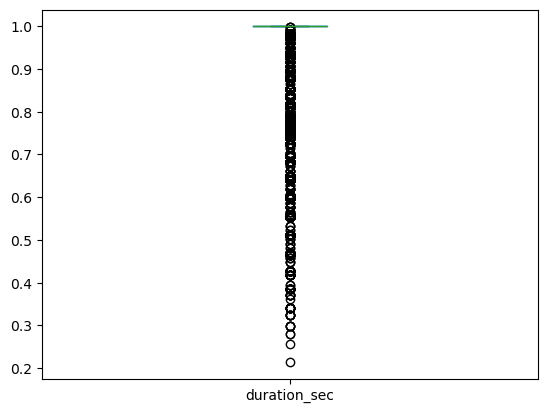

In [2]:
keywords.info()                    
keywords.describe()                
                                   
keywords['duration_sec'].plot.box()
plt.show()      

Observamos que el dataset está limpio, por lo que se puede trabajar con él a partir de este estado:

-   Todas las pistas tienen un canal y una frecuencia de muestreo de 16 kHz.
-   la duración media es cercana a 1 segundo, y la duración máxima es de un segundo, con una desviación típica muy baja: casi todas las muestras son de un segundo y la mínima es de 213 msec. Para los propósitos de este estudio es un dataset adecuado, pero es posible que el modelo se sobreajuste a muestras de esta longitud, y habría que tener en  cuenta esto con muestras más largas donde previsiblemente se pueda encontrar más silencio antes y después de la *keyword*.

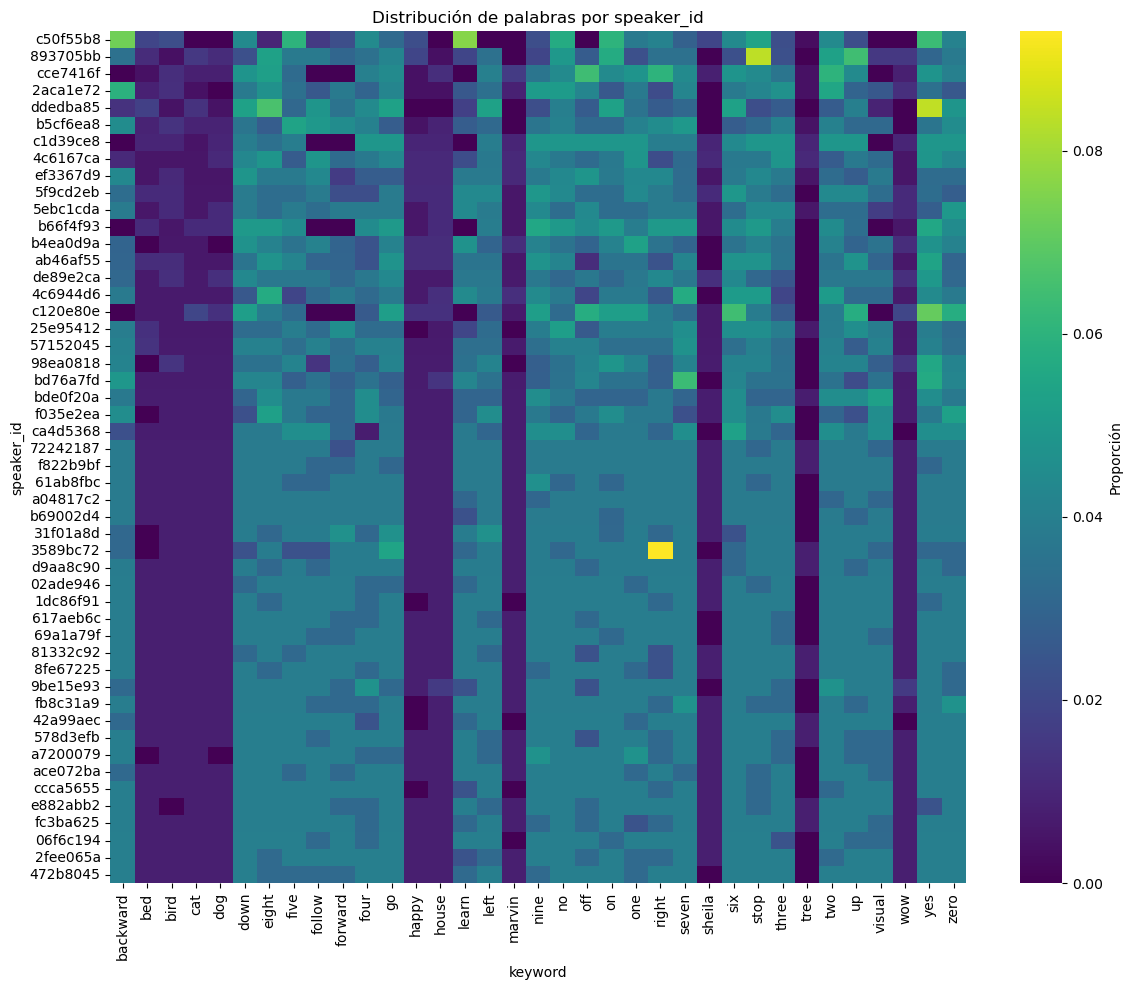

In [4]:
import seaborn as sb                                                              
                                                                                  
def calc_percent(x):                                                              
    return x.size/len(keywords) * 100                                             
                                                                                  
speakers = keywords.groupby('speaker_id').agg(                                    
    n_examples = ('keyword', 'size'),                                             
    prop_examples = ('keyword', calc_percent),                                    
    n_keywords = ('keyword', 'nunique')                                           
).reset_index()                                                                   
                                                                                  
#Heatmap con los 50 hablantes más presentes en el dataset                                                
kw_dist_by_speaker = pd.crosstab(keywords['speaker_id'], keywords['keyword'])     
kw_prop = kw_dist_by_speaker.div(kw_dist_by_speaker.sum(axis=1), axis=0).fillna(0)
top = kw_dist_by_speaker.sum(axis=1).nlargest(50).index                           
plot_df = kw_prop.loc[top]                                                        
                                                                                  
plt.figure(figsize=(12,10))                                                       
sb.heatmap(plot_df, cmap='viridis', cbar_kws={'label':'Proporción'})              
plt.xlabel('keyword')                                                             
plt.ylabel('speaker_id')                                                          
plt.title('Distribución de palabras por speaker_id')                              
plt.tight_layout()                                                                
plt.show()                                                    

En el heatmap se pueden observar una serie de palabras con muy baja representación, que resultan ser las palabras que se introdujeron en el dataset originariamente para distinguir palabras no reconocidas. Antes de valorar incluirlas en las particiones vamos a cuantificar los ejemplos.

In [5]:
infrarep = ['bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow']
others = keywords[~keywords['keyword'].isin(infrarep)]['keyword']                            
                                                                                             
for k in infrarep:                                                                           
    n_k = len(keywords[keywords['keyword'] == k])                                            
    print(f"Muestras de {k} = {n_k}")                                                        
mean_others = others.value_counts().mean()                                                   
print(f"Media de muestras del resto: {mean_others}")                                         

Muestras de bed = 2014
Muestras de bird = 2064
Muestras de cat = 2031
Muestras de dog = 2128
Muestras de happy = 2054
Muestras de house = 2113
Muestras de marvin = 2100
Muestras de sheila = 2022
Muestras de tree = 1759
Muestras de wow = 2123
Media de muestras del resto: 3416.84


Se considera que el número de muestras es suficiente para incluirlas en el entrenamiento.
Hay algún caso de palabras sobrerrepresentadas por un hablante, y algunos casos de hablantes con palabras infrarrepresentadas, por lo que nos aseguraremos de que los conjuntos de test y validation estén equilibrados con respecto a las distintas keywords. 

### Normalización

Antes de realizar las particiones vamos a normalizar las muestras en amplitud. El proceso se aplica sobre cada muestra de manera independiente, por lo que el futuro conjunto de test no se va a ver comprometido por este proceso. Se usará una normalización conservadora a -6.0 dBFS de pico para evitar introducir distorsiones no presentes durante los entrenamientos de los experimentos, donde se prevé usar ganancias aleatorias entre -6 y +6 dBFS. Simplemente como prueba del sistema, ya que desde el punto de vista pragmático no podemos cargar batches porque tendríamos que unificar las duraciones y aún no hemos hecho las particiones, lo vamos a implementar en GPU.

In [6]:
OUT_DIR = Path('/mnt/data/GSC/normalized-dataset')                                              
OUT_DIR.mkdir(parents=True, exist_ok=True)                                                      
TARGET_DBFS = -6.0                                                                              
EPS = 1e-12 #Usamos un valor epsilon para margen de seguridad en cálculos de coma flotante      
                                                                                                
device = torch.device('cuda') #Cambiar a 'cpu' si no se dispone de cuda                         
                                                                                                
#Función para calcular la RMS. Sumamos un pequeño valor para evitar divisiones por 0 en         
                                                                                                
keywords['path_normalized'] = None                                                              
j = 0 #primer índice del dataset. Usaremos j para acceder a información contenida en el filepath
for i in keywords['path']:                                                                      
    waveform, sr = torchaudio.load(str(i))                                                      
    waveform = waveform.to(device)                                                              
                                                                                                
    max_current_peak = waveform.abs().max().clamp_min(EPS);                                     
    current_peak_db = 20.0 ** torch.log10(max_current_peak)                                     
                                                                                                
    needed_gain = (TARGET_DBFS - current_peak_db)                                               
                                                                                                
    vol = torchaudio.transforms.Vol(needed_gain, gain_type='db')                                
    normalized = vol(waveform)                                                                  
                                                                                                
    #Salvamos en disco pasando por cpu                                                                        
    normalized_cpu = normalized.to('cpu')                                                       
    out_path = Path(f"{OUT_DIR}/{keywords.loc[j, 'keyword']}")                                  
    out_path.mkdir(parents=True, exist_ok=True)                                                 
    this_filename = f"/{keywords.loc[j, 'filename']}"                                           
    normalized_path = f"{out_path}{this_filename}"                                              
    torchaudio.save(str(normalized_path), normalized_cpu, sr)                                   
    keywords.at[j, 'path_normalized'] = str(normalized_path)                                    
                                                                                                
    j += 1                                                                                      

Antes de proseguir con la división del dataset, vamos a exportar los datasets en csv:

In [7]:
data.to_csv('FASE2_data.csv')        
noises.to_csv('FASE2_noises.csv')    
keywords.to_csv('FASE2_keywords.csv')

### División del dataset

Vamos a dividir el dataset en conjuntos de train/val/test con porcentajes 80/10/10. Tendremos en cuenta dos criterios:

1.  No puede existir leakage por speaker para no contaminar la fase de test con predicciones sobre hablantes presentes en el conjunto de entrenamiento.
2.  Intentaremos mantener al menos los grupos de test y validación balanceados en cuanto a keywords: se ha intentado usar StratifiedGroupKFold de sklearn para para dividir en 10 splits balanceados sin leakage de speakerid, pero se perdían 11020 ejemplos para el entrenamiento, qyue es más de un 10% del dataset. Por ello, se ha optado por balancear sólo test y validation entre ellos y usar el resto de muestras para training.

Se prueban dos métodos de particionado y finalmente se decide utilizar un particionado que separa por speakerid y además estratifica para balancear las keywords en los tres grupos. La desventaja de este método es que, a cambio de asegurar balanceo de keywords en todos los conjuntos, se pierden 10582 muestras para entrenamiento. El método alternativo usaba todas las muestras para entrenamiento, pero sólo validaba 8 keywords, que se han considerado una muestra insuficientes para los propósitos de este trabajo, ya que suponen sólo un 22.858% de las etiquetas. Se puede encontrar esa alternativa en el anexo I.


In [8]:
from sklearn.model_selection import StratifiedShuffleSplit, GroupShuffleSplit, StratifiedGroupKFold   
import numpy as np                                                                                    
                                                                                                      
RANDOM_STATE = 1234                                                                                   
groups = keywords['speaker_id']                                                                       
y = keywords['keyword']                                                                               
                                                                                                      
stratified_group_split = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)   
                                                                                                      
#Usamos StratifiedGroupKFold para concatenar las distintas particiones de test que genera en los folds
folds = list(stratified_group_split.split(keywords, y, groups=groups))                                
train_idx = np.concatenate([folds[i][1] for i in range(0,7)])                                         
val_idx = folds[8][1]                                                                                 
test_idx = folds[9][1]                                                                                
                                                                                                      
X_train = keywords.iloc[train_idx]                                                                    
y_train = y[train_idx]                                                                                
                                                                                                      
X_val = keywords.iloc[val_idx]                                                                        
y_val = y[val_idx]                                                                                    
                                                                                                      
X_test = keywords.iloc[test_idx]                                                                      
y_test = y[test_idx]                                                                                  
                                                                                                      
X_train.to_csv('FASE2-X_train.csv')                                                                   
X_val.to_csv('FASE2-X_val.csv')                                                                       
X_test.to_csv('FASE2-X_test.csv')                                                                     
y_train.to_csv('FASE2-y_train.csv')                                                                   
y_val.to_csv('FASE2-y_val.csv')                                                                       
y_test.to_csv('FASE2-y_test.csv')                                                                     

Vamos a validar a continuación los conjuntos:

In [9]:
print(y_train.unique())            
print(y_val.unique())              
print(y_test.unique())             
                                   
print(y_train.value_counts())      
print(y_val.value_counts())        
print(y_test.value_counts())       
                                   
len(y_train)+len(y_val)+len(y_test)

<StringArray>
['backward',      'bed',     'bird',      'cat',      'dog',     'down',
    'eight',     'five',   'follow',  'forward',     'four',       'go',
    'happy',    'house',    'learn',     'left',   'marvin',     'nine',
       'no',      'off',       'on',      'one',    'right',    'seven',
   'sheila',      'six',     'stop',    'three',     'tree',      'two',
       'up',   'visual',      'wow',      'yes',     'zero']
Length: 35, dtype: str
<StringArray>
['backward',      'bed',     'bird',      'cat',      'dog',     'down',
    'eight',     'five',   'follow',  'forward',     'four',       'go',
    'happy',    'house',    'learn',     'left',   'marvin',     'nine',
       'no',      'off',       'on',      'one',    'right',    'seven',
   'sheila',      'six',     'stop',    'three',     'tree',      'two',
       'up',   'visual',      'wow',      'yes',     'zero']
Length: 35, dtype: str
<StringArray>
['backward',      'bed',     'bird',      'cat',      'dog',

95247

Comprobamos que no haya leakage entre train, test y val

In [10]:
#Comprobamos ausencia de leakage entre train,test y val    
len(set(X_train['speaker_id']) & set(X_val['speaker_id'])) 
len(set(X_train['speaker_id']) & set(X_test['speaker_id']))
len(set(X_val['speaker_id']) & set(X_test['speaker_id']))  

0

Añadimos un snippet de código para cargar los conjuntos en este punto sin tener que ejecutar lo anterior.

In [11]:
import pandas as pd

X_train = pd.read_csv('FASE2-X_train.csv')
X_val = pd.read_csv('FASE2-X_val.csv')
X_test = pd.read_csv('FASE2-X_test.csv')

y_train = pd.read_csv('FASE2-y_train.csv')
y_val = pd.read_csv('FASE2-y_val.csv')
y_test = pd.read_csv('FASE2-y_test.csv')

Para finalizar con la preparación del dataset,procedemos a codificar las etiquetas ajustando al modelo de train

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()                                        
#Cargar desde csv primero (asume pandas)
y_encoded = le.fit_transform(y_train['keyword'])
yval_encoded = le.transform(y_val['keyword'])
ytest_encoded = le.transform(y_test['keyword'])

print(y_encoded)
print(yval_encoded)
print(ytest_encoded)

train_list = X_train['path_normalized'].tolist()
labels = y_encoded.tolist()                     
                                                
val_list = X_val['path_normalized'].tolist()    
val_labels = yval_encoded.tolist()              

test_list = X_test['path_normalized'].tolist()    
test_labels = ytest_encoded.tolist()          

[ 0  0  0 ... 34 34 34]
[ 0  0  0 ... 34 34 34]
[ 0  0  0 ... 34 34 34]
